In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [3]:
import numpy as np
from stable_baselines3.common.env_checker import check_env

# Sequential DDA environment test

In [4]:
from vimms.Common import POSITIVE
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.features import obs_to_dfs

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
 /opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning:hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.


In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (500, 2000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E5, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE
noise_density = 0.1
noise_max_val = 1e3

In [9]:
mzml_filename = 'Beer_multibeers_1_fullscan1.mzML'
mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                       min_log_intensity=min_log_intensity,
                                       max_log_intensity=max_log_intensity)

2022-03-26 16:54:50.147 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 1109 scans
2022-03-26 16:54:52.028 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 1109 scans


In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
    },
    'noise': {
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol
    }
}

Initialise a new DDA environment that tracks the most intense peaks.

In [11]:
max_peaks = 20
env = DDAEnv(max_peaks, params)
check_env(env)

Generate an initial observation (MS1 scan) -- can be empty

In [12]:
observation = env.reset()
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  log_intensities
 0      0.276056         0.0       0.0         6.901396
 1      0.275401         0.0       0.0         6.885032
 2      0.275086         0.0       0.0         6.877140
 3      0.274485         0.0       0.0         6.862121
 4      0.271241         0.0       0.0         6.781014
 5      0.270957         0.0       0.0         6.773921
 6      0.270089         0.0       0.0         6.752224
 7      0.267600         0.0       0.0         6.689997
 8      0.266969         0.0       0.0         6.674214
 9      0.266680         0.0       0.0         6.667002
 10     0.265923         0.0       0.0         6.648066
 11     0.264916         0.0       0.0         6.622893
 12     0.264730         0.0       0.0         6.618251
 13     0.262289         0.0       0.0         6.557214
 14     0.261912         0.0       0.0         6.547811
 15     0.260068         0.0       0.0         6.501709
 16     0.259503         0.0       0.0         6

In [13]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1.], dtype=float32)

In [14]:
env.features

[mz=258.30010852605744 rt=200 intensity=993.6609951539002 (0.2760558438932954),
 mz=430.1229430229866 rt=200 intensity=977.5327198462365 (0.2754012705715116),
 mz=385.4449777214561 rt=200 intensity=969.8482009442571 (0.27508558261516336),
 mz=558.190073201062 rt=200 intensity=955.3908798525218 (0.2744848222006373),
 mz=296.8316717965323 rt=200 intensity=880.9619084469772 (0.2712405755311351),
 mz=265.68980176148693 rt=200 intensity=874.7351214417072 (0.2709568448870732),
 mz=539.7182983322346 rt=200 intensity=855.960727863533 (0.27008897985700747),
 mz=365.4560766770265 rt=200 intensity=804.3200197998109 (0.2675998889824439),
 mz=267.1709041700152 rt=200 intensity=791.7252114738626 (0.26696857505607086),
 mz=316.20650345036347 rt=200 intensity=786.0357852984686 (0.266680092790495),
 mz=228.33658892624643 rt=200 intensity=771.291402510504 (0.2659226502450498),
 mz=372.68524990475976 rt=200 intensity=752.1177130273958 (0.2649157137992358),
 mz=525.0801106859626 rt=200 intensity=748.63486

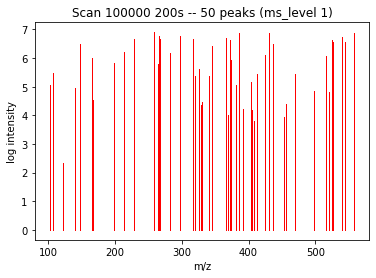

In [15]:
env.render()

Generate 5 ms1 scans

In [16]:
for i in range(5):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.756063         0.0       0.0        18.901582
 1      0.619692         0.0       0.0        15.492300
 2      0.395683         0.0       0.0         9.892074
 3      0.276098         0.0       0.0         6.902460
 4      0.272467         0.0       0.0         6.811675
 5      0.271405         0.0       0.0         6.785120
 6      0.270623         0.0       0.0         6.765582
 7      0.269429         0.0       0.0         6.735729
 8      0.267794         0.0       0.0         6.694852
 9      0.267754         0.0       0.0         6.693839
 10     0.267225         0.0       0.0         6.680614
 11     0.267072         0.0       0.0         6.676810
 12     0.266495         0.0       0.0         6.662370
 13     0.263595         0.0       0.0         6.589865
 14     0.260357         0.0       0.0         6.508925
 15     0.259603         0.0       0.0         6.490073
 16     0.257223         0.0       0.0         6

In [17]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1.], dtype=float32)

In [18]:
env.features

[mz=332.9540728493414 rt=202.00000000000003 intensity=161753204.32194853 (0.7560632920594272),
 mz=276.2765768576819 rt=202.00000000000003 intensity=5348357.972174667 (0.619692006026937),
 mz=268.1717724571579 rt=202.00000000000003 intensity=19773.022804619173 (0.3956829521216527),
 mz=133.69729449349984 rt=202.00000000000003 intensity=994.7186048673167 (0.2760983955192784),
 mz=190.80963397059378 rt=202.00000000000003 intensity=908.3908866036974 (0.2724669911128221),
 mz=127.84434154657878 rt=202.00000000000003 intensity=884.5860147463662 (0.27140479022468594),
 mz=183.09167311284358 rt=202.00000000000003 intensity=867.4707694849704 (0.27062327264540526),
 mz=203.58945505026747 rt=202.00000000000003 intensity=841.9570396914639 (0.26942915964786274),
 mz=583.9058956271903 rt=202.00000000000003 intensity=808.2339110653143 (0.26779406042074155),
 mz=514.6926652265754 rt=202.00000000000003 intensity=807.4163287364235 (0.2677535772825703),
 mz=263.21674201311004 rt=202.00000000000003 inten

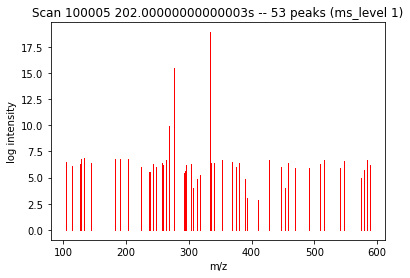

In [22]:
env.render()

Target the most intense precursor for fragmentation, and generate an MS2 scan from that

In [23]:
action = 0
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.8378528903993124
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.756063         0.2  0.026667        18.901582
 1      0.619692         0.0  0.000000        15.492300
 2      0.395683         0.0  0.000000         9.892074
 3      0.276098         0.0  0.000000         6.902460
 4      0.272467         0.0  0.000000         6.811675
 5      0.271405         0.0  0.000000         6.785120
 6      0.270623         0.0  0.000000         6.765582
 7      0.269429         0.0  0.000000         6.735729
 8      0.267794         0.0  0.000000         6.694852
 9      0.267754         0.0  0.000000         6.693839
 10     0.267225         0.0  0.000000         6.680614
 11     0.267072         0.0  0.000000         6.676810
 12     0.266495         0.0  0.000000         6.662370
 13     0.263595         0.0  0.000000         6.589865
 14     0.260357         0.0  0.000000         6.508925
 15     0.259603         0.0  0.000000         6.490073
 16     0.257223         0.0  0.000000         6

In [24]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1.], dtype=float32)

In [25]:
env.features

[mz=332.9540728493414 rt=202.00000000000003 intensity=161753204.32194853 (0.7560632920594272),
 mz=276.2765768576819 rt=202.00000000000003 intensity=5348357.972174667 (0.619692006026937),
 mz=268.1717724571579 rt=202.00000000000003 intensity=19773.022804619173 (0.3956829521216527),
 mz=133.69729449349984 rt=202.00000000000003 intensity=994.7186048673167 (0.2760983955192784),
 mz=190.80963397059378 rt=202.00000000000003 intensity=908.3908866036974 (0.2724669911128221),
 mz=127.84434154657878 rt=202.00000000000003 intensity=884.5860147463662 (0.27140479022468594),
 mz=183.09167311284358 rt=202.00000000000003 intensity=867.4707694849704 (0.27062327264540526),
 mz=203.58945505026747 rt=202.00000000000003 intensity=841.9570396914639 (0.26942915964786274),
 mz=583.9058956271903 rt=202.00000000000003 intensity=808.2339110653143 (0.26779406042074155),
 mz=514.6926652265754 rt=202.00000000000003 intensity=807.4163287364235 (0.2677535772825703),
 mz=263.21674201311004 rt=202.00000000000003 inten

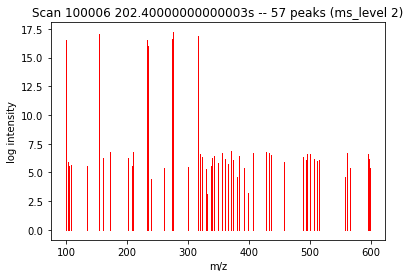

In [26]:
env.render()

Target the next most intense precursor for fragmentation, and generate an MS2 scan

In [27]:
action = 1
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.7034172261200949
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.756063         0.2      0.04        18.901582
 1      0.619692         0.2      0.04        15.492300
 2      0.395683         0.0      0.00         9.892074
 3      0.276098         0.0      0.00         6.902460
 4      0.272467         0.0      0.00         6.811675
 5      0.271405         0.0      0.00         6.785120
 6      0.270623         0.0      0.00         6.765582
 7      0.269429         0.0      0.00         6.735729
 8      0.267794         0.0      0.00         6.694852
 9      0.267754         0.0      0.00         6.693839
 10     0.267225         0.0      0.00         6.680614
 11     0.267072         0.0      0.00         6.676810
 12     0.266495         0.0      0.00         6.662370
 13     0.263595         0.0      0.00         6.589865
 14     0.260357         0.0      0.00         6.508925
 15     0.259603         0.0      0.00         6.490073
 16     0.257223         0.0      0.00         6

In [28]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1.], dtype=float32)

In [29]:
env.features

[mz=332.9540728493414 rt=202.00000000000003 intensity=161753204.32194853 (0.7560632920594272),
 mz=276.2765768576819 rt=202.00000000000003 intensity=5348357.972174667 (0.619692006026937),
 mz=268.1717724571579 rt=202.00000000000003 intensity=19773.022804619173 (0.3956829521216527),
 mz=133.69729449349984 rt=202.00000000000003 intensity=994.7186048673167 (0.2760983955192784),
 mz=190.80963397059378 rt=202.00000000000003 intensity=908.3908866036974 (0.2724669911128221),
 mz=127.84434154657878 rt=202.00000000000003 intensity=884.5860147463662 (0.27140479022468594),
 mz=183.09167311284358 rt=202.00000000000003 intensity=867.4707694849704 (0.27062327264540526),
 mz=203.58945505026747 rt=202.00000000000003 intensity=841.9570396914639 (0.26942915964786274),
 mz=583.9058956271903 rt=202.00000000000003 intensity=808.2339110653143 (0.26779406042074155),
 mz=514.6926652265754 rt=202.00000000000003 intensity=807.4163287364235 (0.2677535772825703),
 mz=263.21674201311004 rt=202.00000000000003 inten

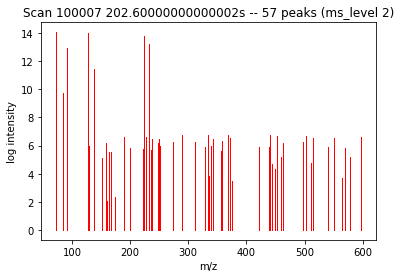

In [30]:
env.render()

Repeat targeting of the same precursor produces a small or no reward

In [31]:
for i in range(10):
    action = 0
    observation, reward, done, info = env.step(action)
    print('reward', reward)
    # print('done', done)
    # pp.pprint(observation)
    # env.render()

reward 0.0038891923776722594
reward 0.0019205961888360435
reward 0.0019045961888360808
reward 0.001888596188836118
reward 0.0018725961888361553
reward 0.0018565961888361926
reward 0.0018405961888360877
reward 0.001824596188836125
reward 0.0018085961888361624
reward 0.0017925961888361997


In [32]:
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  log_intensities
 0      0.756063         1.0  0.173333        18.901582
 1      0.619692         0.2  0.173333        15.492300
 2      0.395683         0.0  0.000000         9.892074
 3      0.276098         0.0  0.000000         6.902460
 4      0.272467         0.0  0.000000         6.811675
 5      0.271405         0.0  0.000000         6.785120
 6      0.270623         0.0  0.000000         6.765582
 7      0.269429         0.0  0.000000         6.735729
 8      0.267794         0.0  0.000000         6.694852
 9      0.267754         0.0  0.000000         6.693839
 10     0.267225         0.0  0.000000         6.680614
 11     0.267072         0.0  0.000000         6.676810
 12     0.266495         0.0  0.000000         6.662370
 13     0.263595         0.0  0.000000         6.589865
 14     0.260357         0.0  0.000000         6.508925
 15     0.259603         0.0  0.000000         6.490073
 16     0.257223         0.0  0.000000         6

In [33]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1.], dtype=float32)

In [34]:
env.features

[mz=332.9540728493414 rt=202.00000000000003 intensity=161753204.32194853 (0.7560632920594272),
 mz=276.2765768576819 rt=202.00000000000003 intensity=5348357.972174667 (0.619692006026937),
 mz=268.1717724571579 rt=202.00000000000003 intensity=19773.022804619173 (0.3956829521216527),
 mz=133.69729449349984 rt=202.00000000000003 intensity=994.7186048673167 (0.2760983955192784),
 mz=190.80963397059378 rt=202.00000000000003 intensity=908.3908866036974 (0.2724669911128221),
 mz=127.84434154657878 rt=202.00000000000003 intensity=884.5860147463662 (0.27140479022468594),
 mz=183.09167311284358 rt=202.00000000000003 intensity=867.4707694849704 (0.27062327264540526),
 mz=203.58945505026747 rt=202.00000000000003 intensity=841.9570396914639 (0.26942915964786274),
 mz=583.9058956271903 rt=202.00000000000003 intensity=808.2339110653143 (0.26779406042074155),
 mz=514.6926652265754 rt=202.00000000000003 intensity=807.4163287364235 (0.2677535772825703),
 mz=263.21674201311004 rt=202.00000000000003 inten

Making an invalid move produces negative reward.

In [35]:
action = 9 # no precursor to fragment at this index
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.756063         1.0  0.186667        18.901582
 1      0.619692         0.2  0.186667        15.492300
 2      0.395683         0.0  0.000000         9.892074
 3      0.276098         0.0  0.000000         6.902460
 4      0.272467         0.0  0.000000         6.811675
 5      0.271405         0.0  0.000000         6.785120
 6      0.270623         0.0  0.000000         6.765582
 7      0.269429         0.0  0.000000         6.735729
 8      0.267794         0.0  0.000000         6.694852
 9      0.267754         0.2  0.186667         6.693839
 10     0.267225         0.0  0.000000         6.680614
 11     0.267072         0.0  0.000000         6.676810
 12     0.266495         0.0  0.000000         6.662370
 13     0.263595         0.0  0.000000         6.589865
 14     0.260357         0.0  0.000000         6.508925
 15     0.259603         0.0  0.000000         6.490073
 16     0.257223         0.0  0.000000         6

In [36]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1.], dtype=float32)

In [37]:
env.features

[mz=332.9540728493414 rt=202.00000000000003 intensity=161753204.32194853 (0.7560632920594272),
 mz=276.2765768576819 rt=202.00000000000003 intensity=5348357.972174667 (0.619692006026937),
 mz=268.1717724571579 rt=202.00000000000003 intensity=19773.022804619173 (0.3956829521216527),
 mz=133.69729449349984 rt=202.00000000000003 intensity=994.7186048673167 (0.2760983955192784),
 mz=190.80963397059378 rt=202.00000000000003 intensity=908.3908866036974 (0.2724669911128221),
 mz=127.84434154657878 rt=202.00000000000003 intensity=884.5860147463662 (0.27140479022468594),
 mz=183.09167311284358 rt=202.00000000000003 intensity=867.4707694849704 (0.27062327264540526),
 mz=203.58945505026747 rt=202.00000000000003 intensity=841.9570396914639 (0.26942915964786274),
 mz=583.9058956271903 rt=202.00000000000003 intensity=808.2339110653143 (0.26779406042074155),
 mz=514.6926652265754 rt=202.00000000000003 intensity=807.4163287364235 (0.2677535772825703),
 mz=263.21674201311004 rt=202.00000000000003 inten

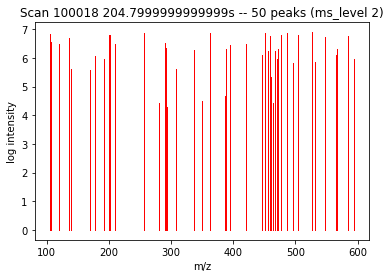

In [38]:
env.render()

Generate lots of MS1 scans

In [39]:
for i in range(100):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -0.1
done False


(    intensities  fragmented  excluded  log_intensities
 0      0.883228         0.0       0.0        22.080696
 1      0.881758         0.0       0.0        22.043948
 2      0.868609         0.0       0.0        21.715227
 3      0.857798         0.0       0.0        21.444947
 4      0.826848         0.0       0.0        20.671199
 5      0.822967         0.0       0.0        20.574178
 6      0.819178         0.0       0.0        20.479458
 7      0.817534         0.0       0.0        20.438357
 8      0.794996         0.0       0.0        19.874901
 9      0.791270         0.0       0.0        19.781751
 10     0.754827         0.0       0.0        18.870681
 11     0.749464         0.0       0.0        18.736604
 12     0.747453         0.0       0.0        18.686317
 13     0.734239         0.0       0.0        18.355982
 14     0.730178         0.0       0.0        18.254440
 15     0.721687         0.0       0.0        18.042180
 16     0.719829         0.0       0.0        17

In [40]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1.], dtype=float32)

In [41]:
env.features

[mz=116.63706130313902 rt=244.60000000000045 intensity=3886191734.544252 (0.883227821060218),
 mz=118.32978971073804 rt=244.60000000000045 intensity=3745975955.3973517 (0.8817579208882804),
 mz=252.04809643456352 rt=244.60000000000045 intensity=2696518000.415777 (0.868609085927733),
 mz=183.08298980822298 rt=244.60000000000045 intensity=2057890021.3467855 (0.8577978813340601),
 mz=252.06047692004228 rt=244.60000000000045 intensity=949265699.8272948 (0.8268479718452266),
 mz=155.84384354814955 rt=244.60000000000045 intensity=861493844.1906224 (0.822967138738074),
 mz=116.67897665302525 rt=244.60000000000045 intensity=783637836.6151707 (0.8191783011397282),
 mz=332.9540728493414 rt=244.60000000000045 intensity=752082818.6536899 (0.8175342802815415),
 mz=173.34864195046913 rt=244.60000000000045 intensity=428114386.8036002 (0.7949960390690278),
 mz=223.10791508814413 rt=244.60000000000045 intensity=390036437.16073567 (0.7912700288536422),
 mz=442.35516385903816 rt=244.60000000000045 intens

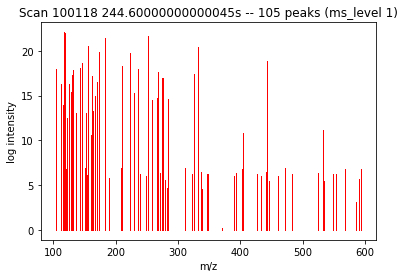

In [42]:
env.render()